In [8]:
import sys
sys.path.append('..')

In [9]:
from src.l1_tools import *
import pandas as pd
import matplotlib.pyplot as plt
import json


In [10]:
df = pd.read_csv("../data/Case_1_and_2/processed/clear_sky_mean_profiles.csv")

analog_parallel_clear = df["RCS_04"].values
analog_perpendicular_clear = df["RCS_02"].values
photocounting_parallel_clear = df["RCS_05"].values
photocounting_perpendicular_clear = df["RCS_03"].values

altitude = df["Altitude_m"].values


print(np.shape(altitude))


(4000,)


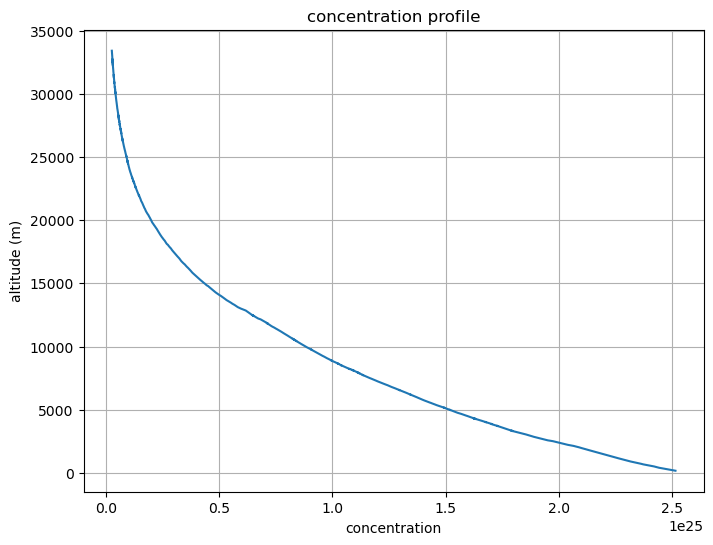

In [12]:
rs_file="../data/Case_1_and_2/raw/rs_2a_GRUAN_TRP_M10_20250704_231547_v2.0.1.nc"

conc , alt_rs , temp = conc_calculation(rs_file)

plt.figure(figsize=(8,6))
plt.plot(conc, alt_rs)
plt.title("concentration profile")
plt.xlabel("concentration")
plt.ylabel("altitude (m)")
plt.grid()
plt.show()

In [13]:
depolarization_ratio_mol = 0.004
AMB_clear  , beta_ray , alpha_ray =  calculate_AMB_clear( conc ,alt_rs, altitude  )
AMB_clear_parallel = AMB_clear / (1 + depolarization_ratio_mol)
AMB_clear_perpendicular = (AMB_clear * depolarization_ratio_mol )/ (1 + depolarization_ratio_mol)


beta_ray_parallel = beta_ray / (1 + depolarization_ratio_mol)
beta_ray_perpendicular = (beta_ray * depolarization_ratio_mol )/ (1 + depolarization_ratio_mol)



In [14]:
AMB_clear =remove_nans_interpolation(AMB_clear, altitude)
AMB_clear_parallel =remove_nans_interpolation(AMB_clear_parallel, altitude)
AMB_clear_perpendicular =remove_nans_interpolation(AMB_clear_perpendicular, altitude)

beta_ray = remove_nans_interpolation(beta_ray, altitude)
beta_ray_parallel = remove_nans_interpolation(beta_ray_parallel, altitude)
beta_ray_perpendicular = remove_nans_interpolation(beta_ray_perpendicular, altitude)   

### calibration for analog 

In [15]:
# filtering
analog_parallel_clear=gaussian_filter(analog_parallel_clear , altitude , max_sigma=5  )
analog_perpendicular_clear=gaussian_filter(analog_perpendicular_clear , altitude , max_sigma=5  )  


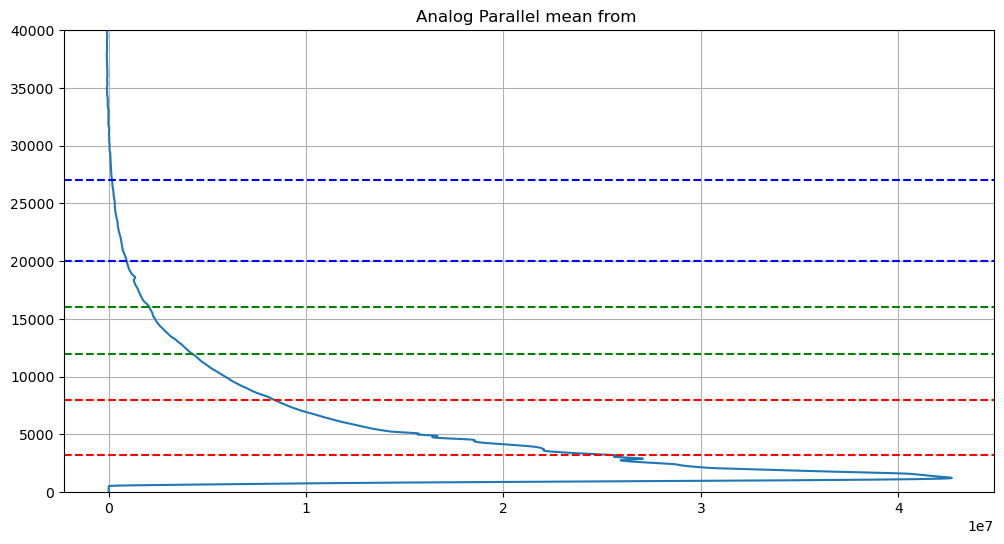

In [16]:

mask1_analog_par=[3200 , 8000]
mask2_analog_par=[12000 , 16000]
mask3_analog_par=[20000 , 27000]



plt.figure(figsize=(12, 6))
plt.title(f"Analog Parallel mean from ")
plt.plot(analog_parallel_clear , altitude)
plt.axhline(y=mask1_analog_par[0], color='r', linestyle='--')
plt.axhline(y=mask1_analog_par[1], color='r', linestyle='--' )
plt.axhline(y=mask2_analog_par[0], color='g', linestyle='--')
plt.axhline(y=mask2_analog_par[1], color='g', linestyle='--')
plt.axhline(y=mask3_analog_par[0], color='b', linestyle='--')
plt.axhline(y=mask3_analog_par[1], color='b', linestyle='--')
plt.ylim(0 , 40000)
plt.grid(True)

# plt.savefig("figures/Analog_Parallel_clear.png")


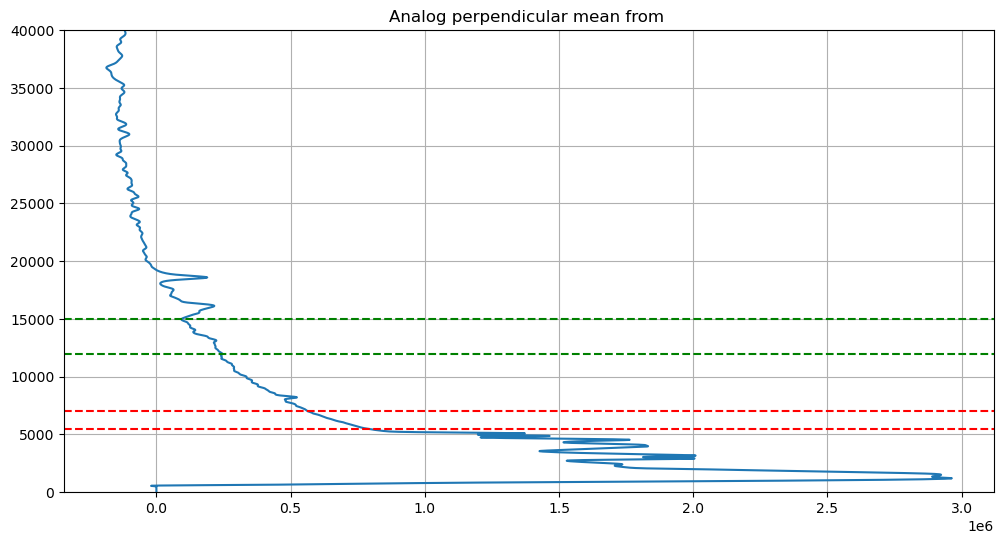

In [17]:

mask1_analog_per=[5500 , 7000]
mask2_analog_per=[12000 , 15000]

plt.figure(figsize=(12, 6))
plt.title(f"Analog perpendicular mean from ")
plt.plot(analog_perpendicular_clear , altitude)

plt.axhline(y=mask1_analog_per[0], color='r', linestyle='--')
plt.axhline(y=mask1_analog_per[1], color='r', linestyle='--' )
plt.axhline(y=mask2_analog_per[0], color='g', linestyle='--')
plt.axhline(y=mask2_analog_per[1], color='g', linestyle='--')


plt.ylim(0 , 40000)
plt.grid(True)
# plt.savefig("figures/Analog_Perpendicular_clear.png")   

In [18]:
K_0_an_par , delta_0_an_par =Calibration(analog_parallel_clear , AMB_clear_parallel , altitude ,  mask1_analog_par , mask2_analog_par , visual=False ) 

K_analog_par, delta_analog_par, result = optimize(analog_parallel_clear, AMB_clear_parallel, altitude,[mask1_analog_par, mask2_analog_par ,mask3_analog_par ],K_0_an_par, delta_0_an_par ,  method='Nelder-Mead')



analog_parallel_clear_corrected = (analog_parallel_clear - delta_analog_par)
ATB_analog_par = K_analog_par * analog_parallel_clear_corrected

print("initiale K:", K_0_an_par, "delta:", delta_0_an_par)
print("optimized K:", K_analog_par, "delta:", delta_analog_par)

initiale K: 1.861124224479428e-13 delta: -506732.5604660246
optimized K: 2.0296566651552527e-13 delta: -166021.5824937446


In [19]:


K_0_an_per , delta_0_an_per =Calibration(analog_perpendicular_clear , AMB_clear_perpendicular , altitude ,  mask1_analog_per , mask2_analog_per , visual=False ) 
K_analog_per, delta_analog_per, result = optimize(analog_perpendicular_clear, AMB_clear_perpendicular, altitude,[mask1_analog_per, mask2_analog_per  ],K_0_an_per, delta_0_an_per ,  method='Nelder-Mead')

analog_perpendicular_clear_corrected =  (analog_perpendicular_clear - delta_analog_per)
ATB_analog_per = K_analog_per * analog_perpendicular_clear_corrected

print("initiale K:", K_0_an_per, "delta:", delta_0_an_per)
print("optimized K:", K_analog_per, "delta:", delta_analog_per)

initiale K: 1.3555160691067701e-14 delta: -29334.894075076427
optimized K: 1.296441353376603e-14 delta: -49663.38194324935


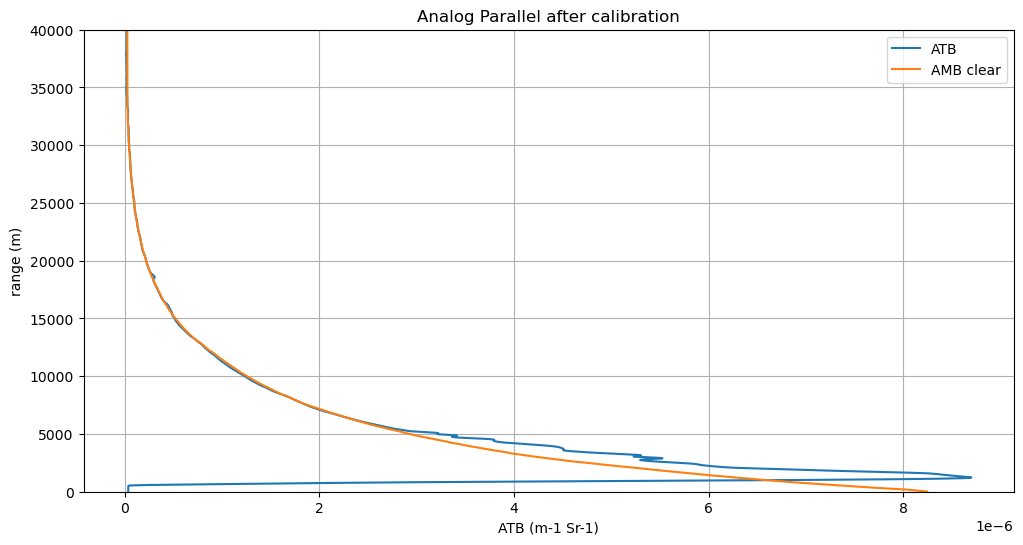

In [20]:
plt.figure(figsize=(12, 6))
plt.title("Analog Parallel after calibration")  

plt.plot(ATB_analog_par , altitude , label="ATB")
plt.plot(AMB_clear_parallel , altitude , label="AMB clear")
plt.ylim((0, 40000))
plt.grid(True)
plt.xlabel("ATB (m-1 Sr-1)")
plt.ylabel("range (m)")
plt.legend()
# plt.savefig("figures/Analog_Parallel_after_calibration.png")



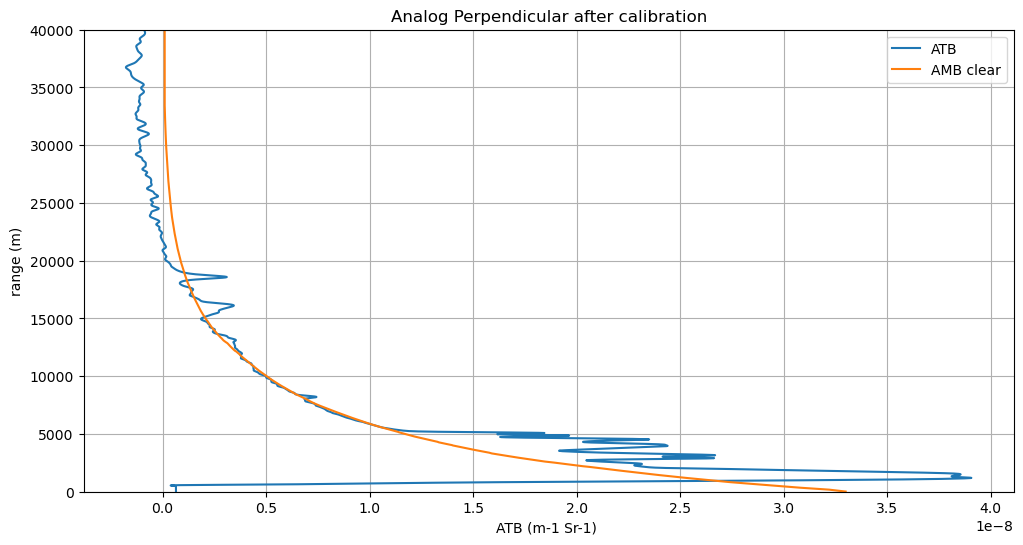

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(ATB_analog_per , altitude, label="ATB")
plt.plot(AMB_clear_perpendicular , altitude, label="AMB clear")
plt.ylim((0, 40000))
plt.grid(True)
plt.title("Analog Perpendicular after calibration")
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.legend()
# plt.savefig("figures/Analog_Perpendicular_after_calibration.png")



### calibration for photocounting

In [22]:
# filtering 
photocounting_parallel_clear=gaussian_filter(photocounting_parallel_clear , altitude , max_sigma=5  )
photocounting_perpendicular_clear=gaussian_filter(photocounting_perpendicular_clear , altitude , max_sigma=5  )


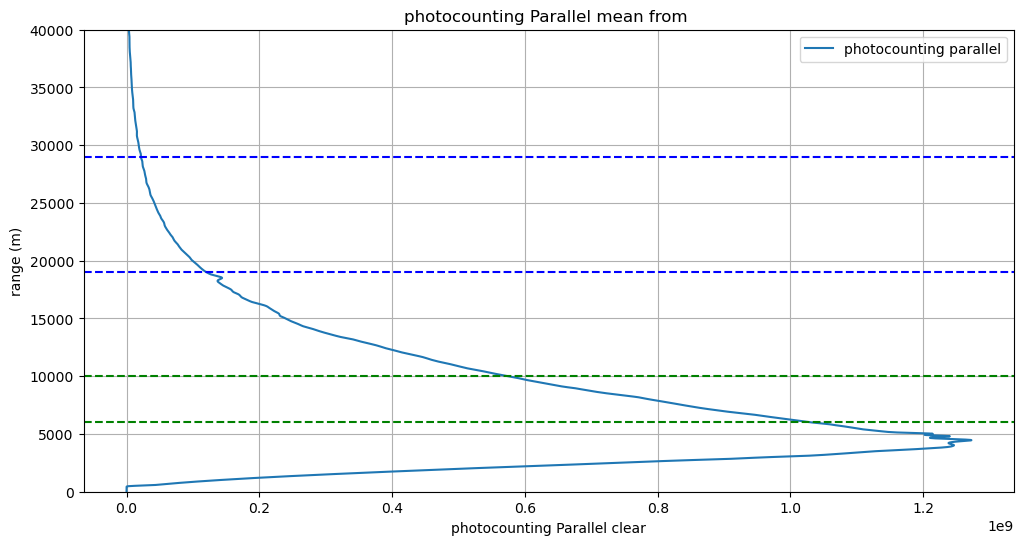

In [23]:


mask1_photo_par=[6000 , 10000]
mask2_photo_par=[19000 , 29000]



plt.figure(figsize=(12, 6))
plt.title(f"photocounting Parallel mean from ")
plt.plot(photocounting_parallel_clear , altitude, label="photocounting parallel")
plt.axhline(y=mask1_photo_par[0], color='g', linestyle='--')
plt.axhline(y=mask1_photo_par[1], color='g', linestyle='--')
plt.axhline(y=mask2_photo_par[0], color='b', linestyle='--')
plt.axhline(y=mask2_photo_par[1], color='b', linestyle='--')
plt.ylim(0 , 40000)
plt.grid(True)
plt.xlabel("photocounting Parallel clear")
plt.ylabel("range (m)")
plt.legend()
# plt.savefig("figures/Photocounting_Parallel_clear.png")




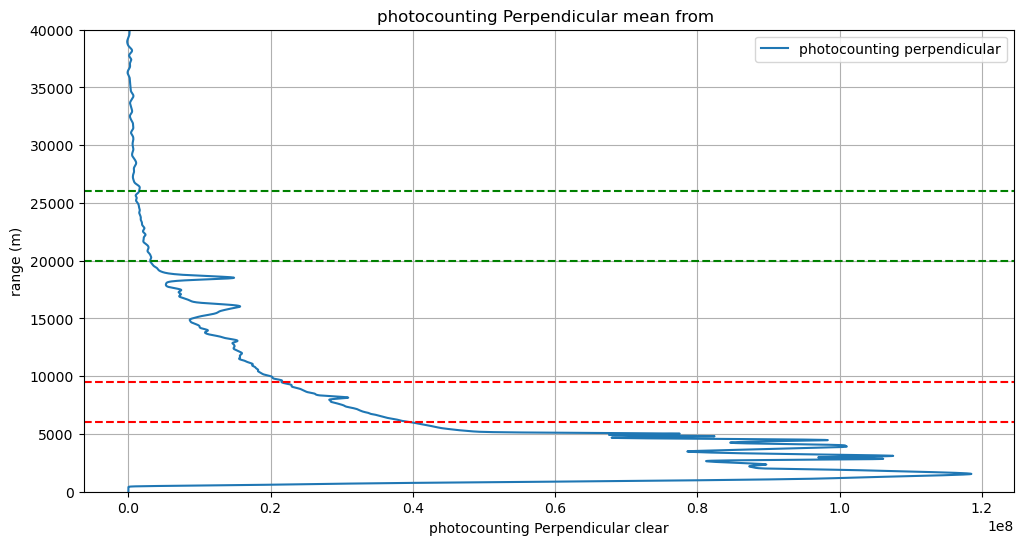

In [24]:


mask1_photo_per=[6000 , 9500]
mask2_photo_per=[20000 , 26000]

plt.figure(figsize=(12, 6))
plt.title(f"photocounting Perpendicular mean from ")
plt.plot(photocounting_perpendicular_clear , altitude, label="photocounting perpendicular")
plt.axhline(y=mask1_photo_per[0], color='r', linestyle='--')
plt.axhline(y=mask1_photo_per[1], color='r', linestyle='--' )
plt.axhline(y=mask2_photo_per[0], color='g', linestyle='--')
plt.axhline(y=mask2_photo_per[1], color='g', linestyle='--')
plt.ylim(0 , 40000)
plt.grid(True)
plt.xlabel("photocounting Perpendicular clear")
plt.ylabel("range (m)")
plt.legend()

# plt.savefig("figures/Photocounting_Perpendicular_clear.png")




In [25]:
K_0_ph_par , delta_0_ph_par =Calibration(photocounting_parallel_clear , AMB_clear_parallel , altitude ,  mask1_photo_par , mask2_photo_par , visual=False ) 

K_ph_par, delta_ph_par, result = optimize(photocounting_parallel_clear, AMB_clear_parallel, altitude,[ mask1_photo_par , mask2_photo_par],K_0_ph_par, delta_0_ph_par ,  method='Nelder-Mead')
photocounting_parallel_clear_corrected = photocounting_parallel_clear - delta_ph_par

ATB_ph_par = K_ph_par * photocounting_parallel_clear_corrected

print("initiale K:", K_0_ph_par, "delta:", delta_0_ph_par)
print("optimized K:", K_ph_par, "delta:", delta_ph_par)

initiale K: 2.240604611781371e-15 delta: 572649.6980829394
optimized K: 2.1942069736149495e-15 delta: -885749.9924823227


In [26]:


K_0_ph_per , delta_0_ph_per =Calibration(photocounting_perpendicular_clear , AMB_clear_perpendicular , altitude ,  mask1_photo_per , mask2_photo_per , visual=False ) 

K_ph_per, delta_ph_per, result = optimize(photocounting_perpendicular_clear, AMB_clear_perpendicular, altitude,[mask1_photo_per, mask2_photo_per , mask2_photo_per],K_0_ph_per, delta_0_ph_per ,  method='Nelder-Mead')


ATB_ph_per = K_ph_per * (photocounting_perpendicular_clear - delta_ph_per)

print("initiale K:", K_0_ph_per, "delta:", delta_0_ph_per)
print("optimized K:", K_ph_per, "delta:", delta_ph_per)

initiale K: 2.463483194524808e-16 delta: -155066.1565744213
optimized K: 2.480127822431167e-16 delta: -140830.10348847398


(0.0, 40000.0)

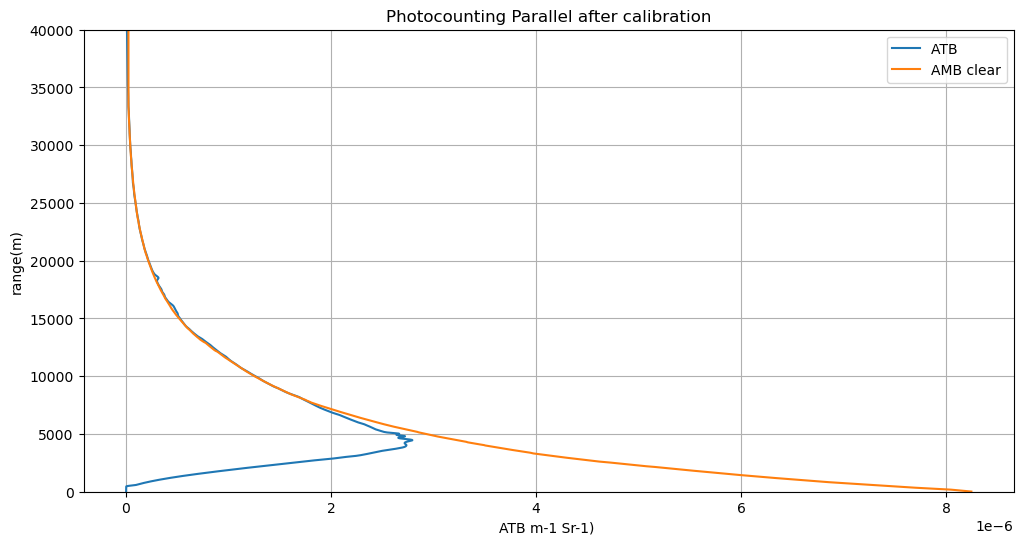

In [27]:

plt.figure(figsize=(12, 6))
plt.title("Photocounting Parallel after calibration")   
plt.plot(ATB_ph_par , altitude, label="ATB ")
plt.plot(AMB_clear_parallel , altitude, label="AMB clear")
plt.grid(True)
plt.ylabel("range(m)")
plt.xlabel("ATB m-1 Sr-1) ")
plt.legend()
plt.ylim((0,40000))
# plt.savefig("figures/Photocounting_Parallel_after_calibration.png")


(0.0, 40000.0)

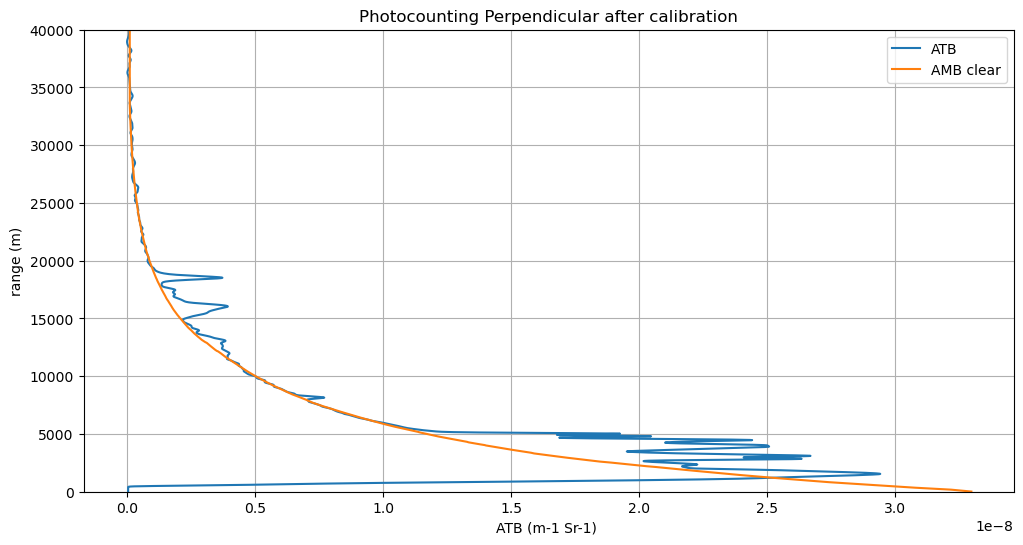

In [28]:
plt.figure(figsize=(12, 6))
plt.title("Photocounting Perpendicular after calibration")
plt.plot(ATB_ph_per , altitude, label="ATB")
plt.plot(AMB_clear_perpendicular , altitude, label="AMB clear")
plt.grid(True)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.legend()
plt.ylim((0,40000))
# plt.savefig("figures/Photocounting_Perpendicular_after_calibration.png")


### coller parallel 

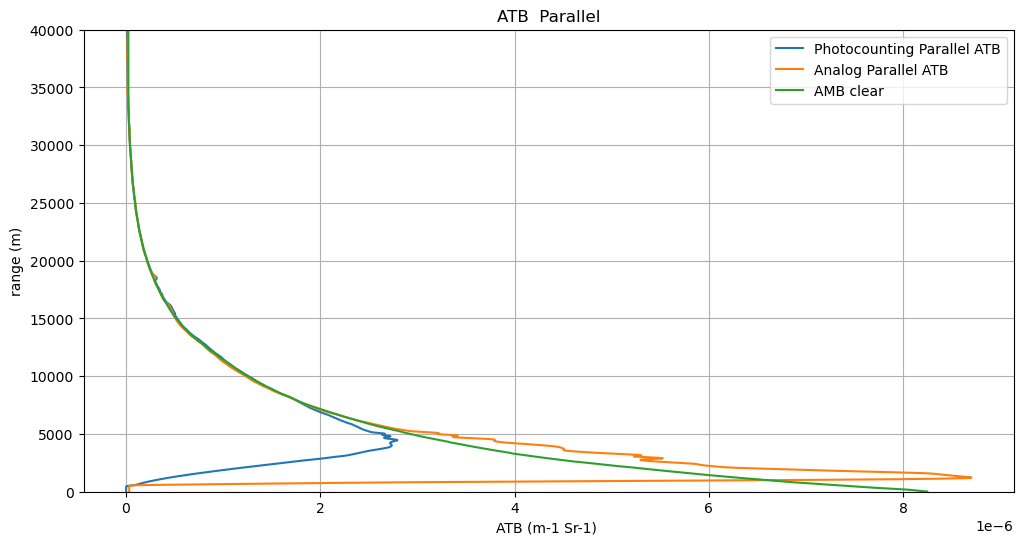

In [29]:
plt.figure(figsize=(12, 6))
plt.title("ATB  Parallel")
plt.plot(ATB_ph_par , altitude , label='Photocounting Parallel ATB')
plt.plot(ATB_analog_par , altitude , label='Analog Parallel ATB')
plt.plot(AMB_clear_parallel , altitude , label='AMB clear')
plt.ylim(0 , 40000)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.legend()
plt.grid(True)

# plt.savefig("figures/Photocounting_Parallel_after_calibration.png")


### coller perpendicular

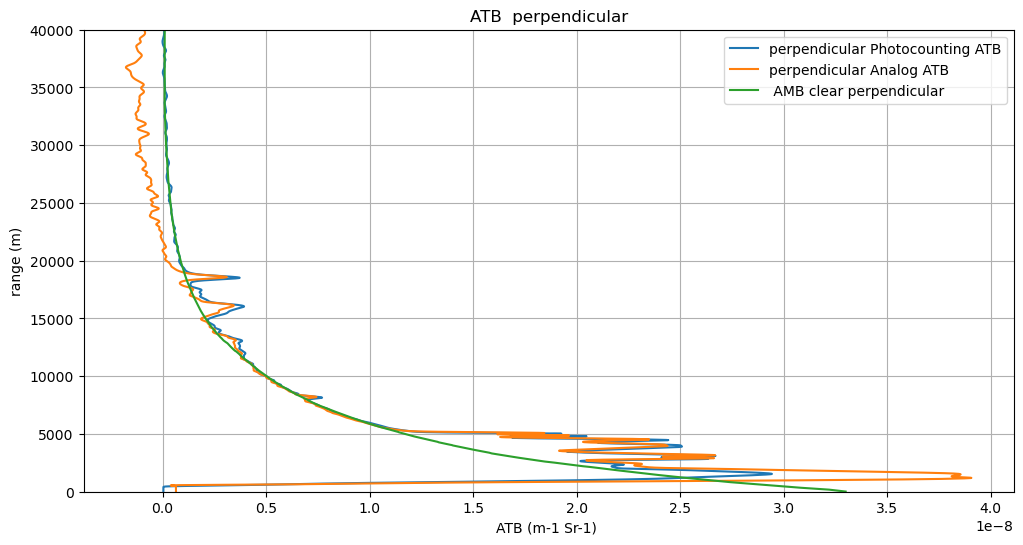

In [30]:
plt.figure(figsize=(12, 6))
plt.title("ATB  perpendicular")
plt.plot(ATB_ph_per, altitude , label='perpendicular Photocounting ATB')
plt.plot(ATB_analog_per, altitude , label='perpendicular Analog ATB')
plt.plot(AMB_clear_perpendicular , altitude , label=' AMB clear perpendicular' )
plt.ylim(0 , 40000)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.legend()
plt.grid(True)
# plt.savefig("figures/ATB_Perpendicular_after_calibration.png")

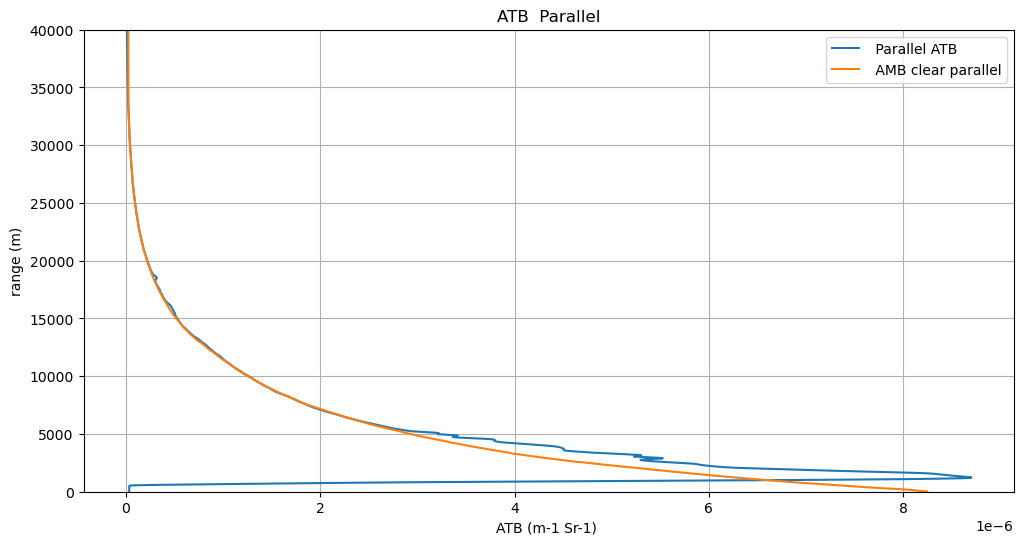

In [31]:
mask_transition_parallel=[8000 , 9500]
ATB_par_Clear= merged_signal_hanning(ATB_analog_par, ATB_ph_par, altitude, transition_start=mask_transition_parallel[0], transition_end=mask_transition_parallel[1])


plt.figure(figsize=(12, 6))
plt.title("ATB  Parallel")
plt.plot(ATB_par_Clear , altitude , label=' Parallel ATB')  
plt.plot(AMB_clear_parallel, altitude , label=' AMB clear parallel' )   
plt.ylim(0 , 40000)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.legend()
plt.grid(True)
# plt.savefig("figures/ATB_Parallel_after_calibration.png")   

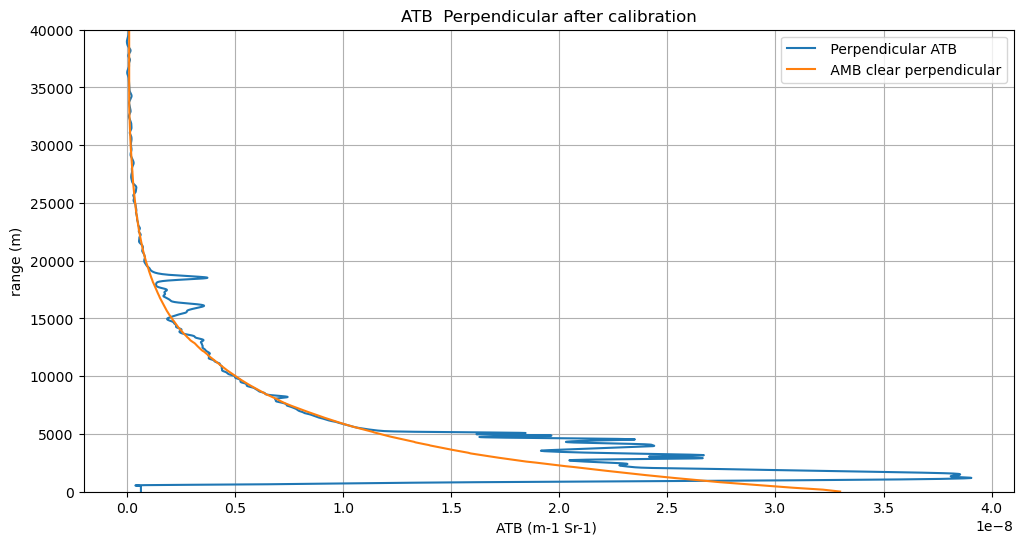

In [32]:
mask_transition_perpendicular=[15000 , 18000]

ATB_per_Clear = merged_signal_hanning(ATB_analog_per, ATB_ph_per, altitude, transition_start=mask_transition_perpendicular[0], transition_end=mask_transition_perpendicular[1])

plt.figure(figsize=(12, 6))
plt.title("ATB  Perpendicular after calibration")
plt.plot(ATB_per_Clear , altitude , label=' Perpendicular ATB')  
plt.plot(AMB_clear_perpendicular, altitude , label=' AMB clear perpendicular' )   
plt.ylim(0 , 40000)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.legend()
plt.grid(True)

In [33]:
calibration_constantes = {
    "K_ph_par": float(K_ph_par),
    "delta_ph_par": float(delta_ph_par),
    "K_ph_per": float(K_ph_per),
    "delta_ph_per": float(delta_ph_per),
    "K_analog_per": float(K_analog_per),
    "delta_analog_per": float(delta_analog_per),
    "K_analog_par": float(K_analog_par),
    "delta_analog_par": float(delta_analog_par),
    
    # Tes nouveaux masques :
    "mask_transition_perpendicular": [15000, 18000],
    "mask_transition_parallel": [8000, 9500]
}

# Sauvegarder dans ton fichier
with open("../data/Case_1_and_2/processed/calibration_constants.json", "w") as f:
    json.dump(calibration_constantes, f, indent=4)